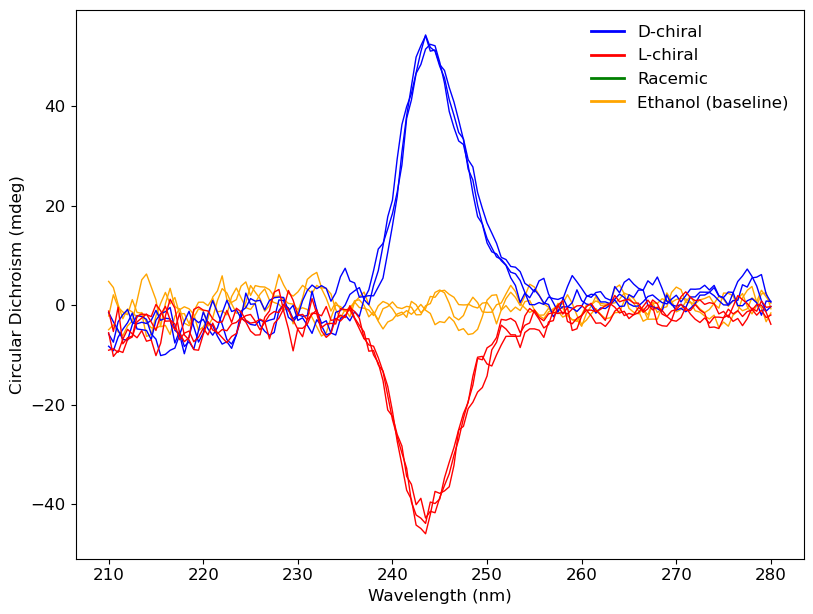

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------- Global font settings ----------------------
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 2

# ---------------------- Paths ----------------------
base_dir = r"/Users/buddhikadezoysa/Downloads/cd"

# ---------------------- Group → color/label mapping (ordered) ----------------------
group_map = {
    "d-chiral": {
        "label": "D-chiral",
        "color": "blue"
    },
    "l-chiral": {
        "label": "L-chiral",
        "color": "red"
    },
    "wetetoh": {
        "label": "Ethanol (baseline)",
        "color": "orange"
    },
}

# ---------------------- Helper function ----------------------
def read_cd_csv(file_path):
    """
    Reads a JASCO CD CSV file and returns wavelength and CD arrays.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()

    # Find start of XYDATA
    xy_start = next(i for i, line in enumerate(lines) if line.strip() == "XYDATA") + 1

    wavelength = []
    cd = []

    for line in lines[xy_start:]:
        line = line.strip()
        if not line or line.startswith("["):
            break

        parts = line.split(",")
        if len(parts) >= 2:
            try:
                wavelength.append(float(parts[0]))
                cd.append(float(parts[1]))
            except ValueError:
                pass

    wavelength = np.array(wavelength)
    cd = np.array(cd)

    # Ensure ascending wavelength order
    idx = np.argsort(wavelength)
    return wavelength[idx], cd[idx]

# ---------------------- Plotting ----------------------
plt.figure(figsize=(8, 6))

for file_name in os.listdir(base_dir):
    if not file_name.lower().endswith(".csv"):
        continue

    file_path = os.path.join(base_dir, file_name)
    x, y = read_cd_csv(file_path)
    fname_lower = file_name.lower()

    for key, info in group_map.items():
        if key in fname_lower:
            plt.plot(
                x,
                y,
                color=info["color"],
                linewidth=1
            )
            break

# ---------------------- Custom legend (fixed order) ----------------------
legend_handles = [
    Line2D([0], [0], color="blue",   lw=2, label="D-chiral"),
    Line2D([0], [0], color="red",    lw=2, label="L-chiral"),
    Line2D([0], [0], color="green",  lw=2, label="Racemic"),
    Line2D([0], [0], color="orange", lw=2, label="Ethanol (baseline)"),
]

plt.legend(handles=legend_handles, fontsize=12, frameon=False)

# ---------------------- Axes styling ----------------------
plt.xlabel("Wavelength (nm)", fontsize=12)
plt.ylabel("Circular Dichroism (mdeg)", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tight_layout()
plt.show()